# Colab reward shaping run v1

本 notebook 用于直接运行改进版实验。

主线保持不变：
- BenchMARL + VMAS
- MAPPO baseline
- reward shaping v1

实现方式：
- 通过 `src/run_reward_shaping_v1.py` 先 patch `VMAS/navigation` 的 reward
- 再在同一进程中调用 `benchmarl.run` 启动训练


## 1. Clone repo

In [1]:
!git clone https://github.com/WonderfulClaire/low_altitude_marl.git
%cd /content/low_altitude_marl
!ls src

Cloning into 'low_altitude_marl'...
remote: Enumerating objects: 126, done.
remote: Counting objects: 100% (126/126), done.
remote: Compressing objects: 100% (120/120), done.
remote: Total 126 (delta 53), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (126/126), 107.42 KiB | 5.11 MiB/s, done.
Resolving deltas: 100% (53/53), done.
/content/low_altitude_marl
analyze_logs.py     notes.md		      run_reward_shaping_v1.py
metrics_summary.py  reward_shaping_design.md  scenario_mapping.md


## 2. Install dependencies

In [2]:
%cd /content/low_altitude_marl
!python -m pip install --upgrade pip
!python -m pip install -r requirements.txt

/content/low_altitude_marl
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 13.4 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 30.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 44.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.4/34.4 MB 38.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 56.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 112.7 MB/s  0:00:00
  Created wheel for vmas: filename=vmas-1.5.2-py3-none-any.whl size=260328 sha256=fb0ccc3975aeca9f281efa00ee

## 3. Read reward design

In [3]:
%cd /content/low_altitude_marl
!sed -n '1,220p' src/reward_shaping_design.md
print('\n' + '='*80 + '\n')
!sed -n '1,240p' src/run_reward_shaping_v1.py

/content/low_altitude_marl
# Reward Shaping v1

## Objective
在 VMAS/navigation 的 MAPPO baseline 上，引入更贴近低空多无人机协同飞行任务的奖励设计，以提升策略在安全性、效率与轨迹质量方面的表现。

## Reward terms
### 1. Goal reward
- 无人机成功到达目标点时给予较大正奖励。
- 用于突出任务完成的重要性。

### 2. Progress reward
- 若当前时间步相比上一步更接近目标点，则给予小幅正奖励。
- 用于缓解稀疏奖励问题，加速训练收敛。

### 3. Collision penalty
- 与障碍物或其他 agent 发生碰撞时给予较大负奖励。
- 用于强调飞行安全约束。

### 4. Risk penalty
- 当无人机距离障碍物过近时给予额外惩罚。
- 用于模拟低空场景中的高风险区域、建筑边界和禁飞区邻近效应。

### 5. Smoothness penalty
- 当连续两个时间步动作变化过大时给予惩罚。
- 用于鼓励更平滑的轨迹，减少抖动与急转弯。

## Proposed formulation
可以将总奖励写成：

R = w1 * R_goal + w2 * R_progress - w3 * R_collision - w4 * R_risk - w5 * R_smooth

其中各权重后续通过实验进行调节。

## Low-altitude scenario mapping
- obstacle -> 建筑物 / 禁飞区 / 高风险区域
- goal -> 配送点 / 巡检点 / 任务点
- collision -> 空域冲突 / 飞行安全风险
- path smoothness -> 飞行稳定性与控制友好性
- progress -> 任务推进效率

## Current plan
1. 先保留原始 MAPPO baseline 作为对照组。
2. 在不推翻现有训练平台的前提下，逐步将 reward shaping 引入任务。
3. 后续通过 episode_reward_mean、reward_mean、collision 相关指标和轨迹可视化比较改进前后的效果。


from __futur

## 4. Check torch and GPU

In [4]:
import torch
print('torch version:', torch.__version__)
print('cuda available:', torch.cuda.is_available())
print('gpu count:', torch.cuda.device_count())
if torch.cuda.is_available():
    print('gpu name:', torch.cuda.get_device_name(0))

torch version: 2.10.0+cpu
cuda available: False
gpu count: 0


## 4. Patch navigation reward (source-level)

In [11]:
import pathlib, textwrap

nav_path = pathlib.Path("/usr/local/lib/python3.12/dist-packages/vmas/scenarios/navigation.py")
src = nav_path.read_text(encoding="utf-8")

if "# [rs_patch]" in src:
    src = src[:src.index("# [rs_patch]")]
    print("旧 patch 已清除")

patch = textwrap.dedent("""
    # [rs_patch]
    import torch as _torch
    _rs_orig_reward = Scenario.reward
    _rs_orig_reset  = Scenario.reset_world_at

    def _rs_reset(self, env_index=None):
      out = _rs_orig_reset(self, env_index)
      if not hasattr(self, "_rs_pd"):
        self._rs_pd = {}
        self._rs_pa = {}

      if env_index is None:
        self._rs_pd.clear()
        self._rs_pa.clear()
      else:
        for d in (self._rs_pd, self._rs_pa):
            for k, v in list(d.items()):
                if isinstance(v, _torch.Tensor) and v.ndim > 0 and env_index < v.shape[0]:
                    v = v.clone()
                    v[env_index] = _torch.nan
                    d[k] = v
      return out

    def _rs_reward(self, agent):
      base = _rs_orig_reward(self, agent)
      if not isinstance(base, _torch.Tensor):
        return base

      r = base.clone()
      zero = _torch.zeros_like(r)

      if not hasattr(self, "_rs_pd"):
        self._rs_pd = {}
        self._rs_pa = {}

      key = getattr(agent, "name", str(id(agent)))
      ap = getattr(getattr(agent, "state", None), "pos", None)
      gp = getattr(getattr(getattr(agent, "goal", None), "state", None), "pos", None)
      dist = _torch.linalg.vector_norm(ap - gp, dim=-1) if (ap is not None and gp is not None) else None

    # progress reward
      prog = zero
      if dist is not None:
        pd = self._rs_pd.get(key)
        if pd is not None and pd.shape == dist.shape:
            valid = _torch.isfinite(pd)
            prog = _torch.where(valid, 0.05 * (pd - dist), zero)
        self._rs_pd[key] = dist.detach().clone()

    # smoothness penalty
      smooth = zero
      act = getattr(getattr(agent, "action", None), "u", None)
      if act is not None:
        pa = self._rs_pa.get(key)
        if pa is not None and pa.shape == act.shape:
            diff = _torch.linalg.vector_norm(act - pa, dim=-1)
            valid = _torch.isfinite(pa).all(dim=-1) if pa.ndim > 1 else _torch.isfinite(pa).all()
            smooth = _torch.where(valid, 0.002 * diff, zero)
        self._rs_pa[key] = act.detach().clone()

    # risk penalty
      risk = zero
      world = getattr(self, "world", None)
      landmarks = getattr(world, "landmarks", []) if world else []
      mc = None

      ar = 0.0
      try:
        ar = float(getattr(getattr(agent, "shape", None), "radius", 0.0))
      except Exception:
        pass

      for lm in landmarks:
        if lm is getattr(agent, "goal", None):
            continue
        lp = getattr(getattr(lm, "state", None), "pos", None)
        if lp is None or ap is None:
            continue
        lr = 0.0
        try:
            lr = float(getattr(getattr(lm, "shape", None), "radius", 0.0))
        except Exception:
            pass
        cl = _torch.linalg.vector_norm(ap - lp, dim=-1) - ar - lr
        mc = cl if mc is None else _torch.minimum(mc, cl)

      if mc is not None:
        thr = _torch.as_tensor(0.05, dtype=mc.dtype, device=mc.device)
        risk_raw = _torch.relu(thr - mc) / thr
        risk = _torch.clamp(0.03 * risk_raw, max=0.03)

      return r + prog - smooth - risk

    Scenario.reward         = _rs_reward
    Scenario.reset_world_at = _rs_reset
    print("[rs_patch] reward shaping patch applied")
""")

src += "\n" + patch
nav_path.write_text(src, encoding="utf-8")

pyc = pathlib.Path("/usr/local/lib/python3.12/dist-packages/vmas/scenarios/__pycache__/navigation.cpython-312.pyc")
if pyc.exists():
    pyc.unlink()

print("patch 写入完成:", nav_path)

旧 patch 已清除
patch 写入完成: /usr/local/lib/python3.12/dist-packages/vmas/scenarios/navigation.py


## 5. Run reward shaping v1 (short run)

In [21]:
%cd /content/low_altitude_marl
import os
os.environ['WANDB_MODE'] = 'disabled'

!python -m benchmarl.run \
  algorithm=mappo \
  task=vmas/navigation \
  experiment.render=false \
  experiment.evaluation=false \
  experiment.max_n_frames=300000 \
  seed=0

/content/low_altitude_marl

Algorithm: mappo, Task: vmas/navigation

Loaded config:

experiment:
  sampling_device: cpu
  train_device: cpu
  buffer_device: cpu
  share_policy_params: true
  prefer_continuous_actions: true
  collect_with_grad: false
  parallel_collection: false
  gamma: 0.99
  lr: 5.0e-05
  adam_eps: 1.0e-06
  adam_extra_kwargs: {}
  clip_grad_norm: true
  clip_grad_val: 5.0
  soft_target_update: true
  polyak_tau: 0.005
  hard_target_update_frequency: 5
  exploration_eps_init: 0.8
  exploration_eps_end: 0.01
  exploration_anneal_frames: null
  max_n_iters: null
  max_n_frames: 300000
  on_policy_collected_frames_per_batch: 6000
  on_policy_n_envs_per_worker: 10
  on_policy_n_minibatch_iters: 45
  on_policy_minibatch_size: 400
  off_policy_collected_frames_per_batch: 6000
  off_policy_n_envs_per_worker: 10
  off_policy_n_optimizer_steps: 1000
  off_policy_train_batch_size: 128
  off_policy_memory_size: 1000000
  off_policy_init_random_frames: 0
  off_policy_use_priorit

## 6. List outputs

In [22]:
%cd /content/low_altitude_marl
!find outputs -maxdepth 3 -type d | sort

/content/low_altitude_marl
outputs
outputs/2026-04-03
outputs/2026-04-03/14-21-25
outputs/2026-04-03/14-21-25/.hydra
outputs/2026-04-03/14-21-25/mappo_navigation_mlp__5bc5fe47_26_04_03-14_21_26
outputs/2026-04-03/17-21-15
outputs/2026-04-03/17-21-15/.hydra
outputs/2026-04-03/17-21-15/mappo_navigation_mlp__5fe481b1_26_04_03-17_21_15
outputs/2026-04-03/17-23-57
outputs/2026-04-03/17-23-57/.hydra
outputs/2026-04-03/17-23-57/mappo_navigation_mlp__4e3bc7d1_26_04_03-17_23_57
outputs/2026-04-03/19-35-12
outputs/2026-04-03/19-35-12/.hydra
outputs/2026-04-03/19-35-12/mappo_navigation_mlp__6b651feb_26_04_03-19_35_12


## 7. Summarize latest run
把下面 `RUN_ROOT` 改成上一个 cell 里最新生成的时间目录。

In [23]:
%cd /content/low_altitude_marl
RUN_ROOT = '/content/low_altitude_marl/outputs/2026-04-03/19-35-12'
!python src/metrics_summary.py "$RUN_ROOT"

/content/low_altitude_marl
Run root: /content/low_altitude_marl/outputs/2026-04-03/19-35-12

=== collection_reward_episode_reward_mean.csv ===
   step     value
0     0 -0.701667
1     1 -0.673722
2     2 -0.695884
3     3 -0.073401
4     4  0.116981
...
    step     value
45    45  0.808103
46    46  0.919814
47    47  0.932648
48    48  0.917142
49    49  0.883203
last value: 0.8832029104232788

=== collection_reward_reward_mean.csv ===
   step     value
0     0 -0.007017
1     1 -0.006737
2     2 -0.006959
3     3 -0.000734
4     4  0.001170
...
    step     value
45    45  0.018388
46    46  0.020257
47    47  0.020284
48    48  0.019706
49    49  0.018931
last value: 0.0189311746507883

=== train_agents_loss_critic.csv ===
   step     value
0     0  0.052852
1     1  0.082058
2     2  0.109795
3     3  0.041794
4     4  0.025912
...
    step     value
45    45  0.033035
46    46  0.020762
47    47  0.023083
48    48  0.026554
49    49  0.028087
last value: 0.0280874315649271

=== 

target: /content/low_altitude_marl/outputs/2026-04-03/19-35-12/mappo_navigation_mlp__6b651feb_26_04_03-19_35_12/mappo_navigation_mlp__6b651feb_26_04_03-19_35_12/scalars/collection_reward_episode_reward_mean.csv


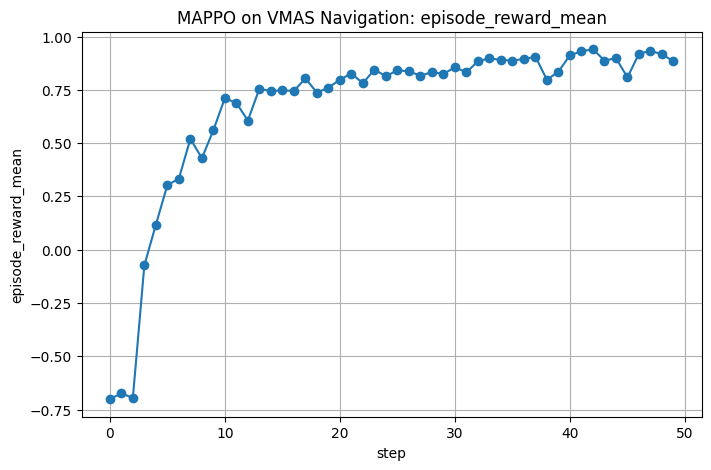

In [24]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

root = Path(RUN_ROOT)
target = None
for p in root.rglob('collection_reward_episode_reward_mean.csv'):
    target = p
    break
print('target:', target)
df = pd.read_csv(target, header=None, names=['step', 'value'])
plt.figure(figsize=(8,5))
plt.plot(df['step'], df['value'], marker='o')
plt.xlabel('step')
plt.ylabel('episode_reward_mean')
plt.title('MAPPO on VMAS Navigation: episode_reward_mean')
plt.grid(True)
plt.show()